In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

In [19]:
file_path = 'audio_example.wav'  
fs_original, audio_data = wavfile.read(file_path)

if len(audio_data.shape) > 1:
    audio_data = audio_data[:, 0]

if audio_data.dtype == np.int16:
    audio_data = audio_data / 32768.0
elif audio_data.dtype == np.int32:
    audio_data = audio_data / 2147483648.0
    
print(f"File gốc: fs = {fs_original} Hz, độ dài = {len(audio_data)} mẫu")
print(f"Thời lượng: {len(audio_data)/fs_original:.2f} giây")

File gốc: fs = 44100 Hz, độ dài = 526073 mẫu
Thời lượng: 11.93 giây


C:\Users\doann\AppData\Local\Temp\ipykernel_4772\3063236733.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_original, audio_data = wavfile.read(file_path)


In [20]:
#8k
fs_8k = 8000
n_samples_8k = int(len(audio_data) * fs_8k / fs_original)
signal_8k = signal.resample(audio_data, n_samples_8k)
t_8k = np.arange(len(signal_8k)) / fs_8k

print(f"8kHz: {len(signal_8k)} mẫu")

8kHz: 95432 mẫu


In [21]:
#16k
fs_16k = 16000
n_samples_16k = int(len(audio_data) * fs_16k / fs_original)
signal_16k = signal.resample(audio_data, n_samples_16k)
t_16k = np.arange(len(signal_16k)) / fs_16k

print(f"16kHz: {len(signal_16k)} mẫu")

16kHz: 190865 mẫu


In [22]:
#44.1kHz
fs_44k = 44100
n_samples_44k = int(len(audio_data) * fs_44k / fs_original)
signal_44k = signal.resample(audio_data, n_samples_44k)
t_44k = np.arange(len(signal_44k)) / fs_44k

print(f"44.1kHz: {len(signal_44k)} mẫu")

44.1kHz: 526073 mẫu


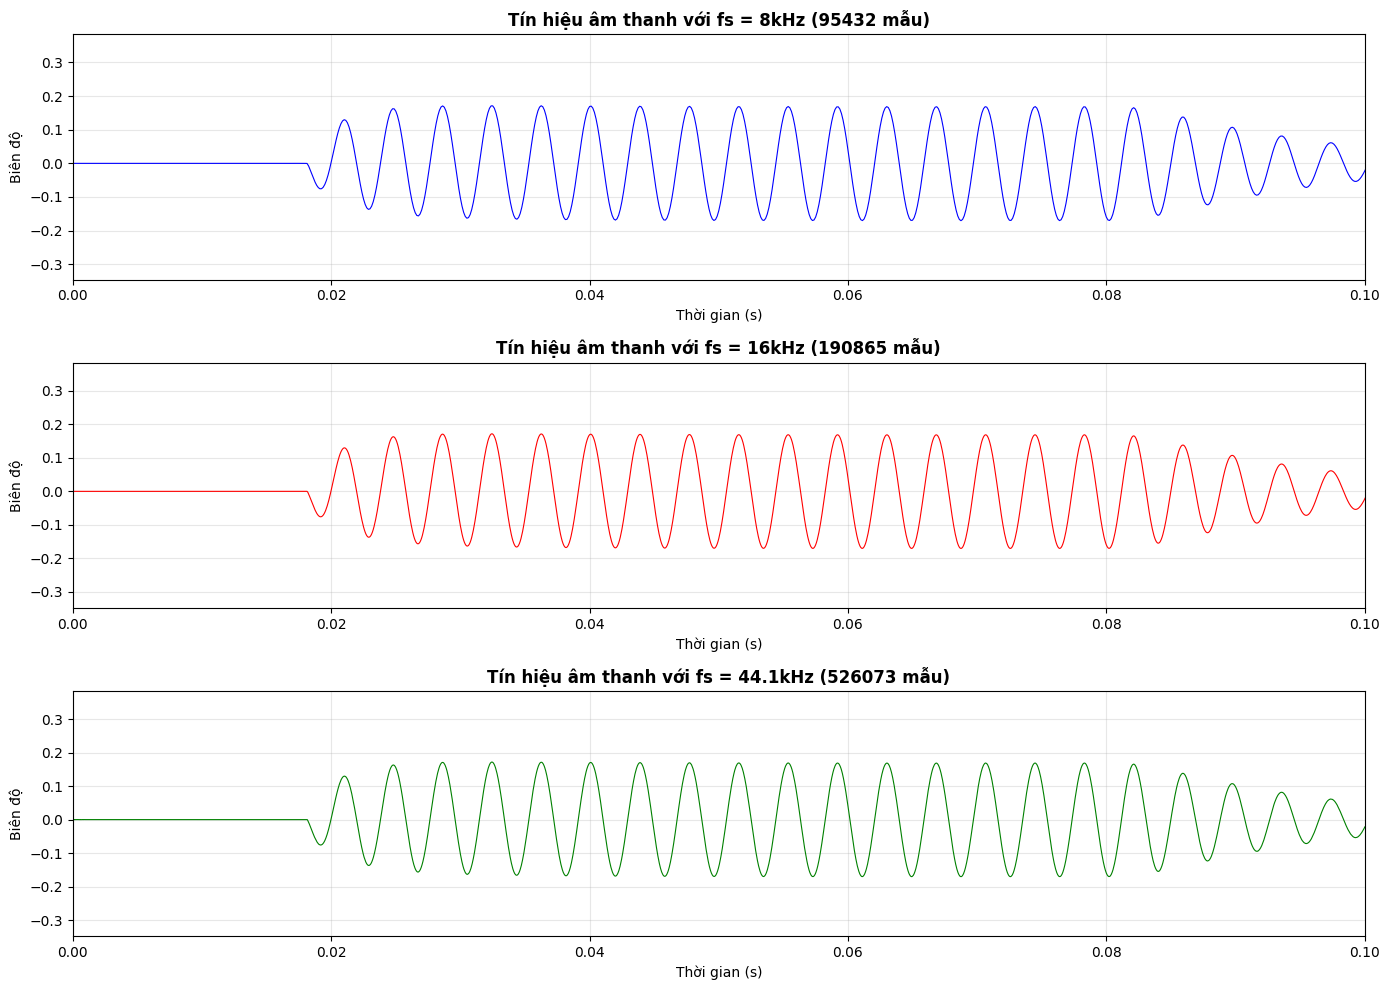

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
time_limit = min(0.1, len(signal_8k)/fs_8k)

#8kHz
axes[0].plot(t_8k, signal_8k, 'b-', linewidth=0.8)
axes[0].set_title(f'Tín hiệu âm thanh với fs = 8kHz ({len(signal_8k)} mẫu)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian (s)')
axes[0].set_ylabel('Biên độ')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, time_limit])

#16kHz
axes[1].plot(t_16k, signal_16k, 'r-', linewidth=0.8)
axes[1].set_title(f'Tín hiệu âm thanh với fs = 16kHz ({len(signal_16k)} mẫu)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thời gian (s)')
axes[1].set_ylabel('Biên độ')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, time_limit])

#44.1kHz
axes[2].plot(t_44k, signal_44k, 'g-', linewidth=0.8)
axes[2].set_title(f'Tín hiệu âm thanh với fs = 44.1kHz ({len(signal_44k)} mẫu)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Thời gian (s)')
axes[2].set_ylabel('Biên độ')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, time_limit])

plt.tight_layout()
plt.show()

In [24]:
print("Độ dài tín hiệu rời rạc (đơn vị: mẫu)")
print("=" * 50)
print(f"fs = 8kHz:    {len(signal_8k)} mẫu")
print(f"fs = 16kHz:   {len(signal_16k)} mẫu")
print(f"fs = 44.1kHz: {len(signal_44k)} mẫu")
print("=" * 50)

Độ dài tín hiệu rời rạc (đơn vị: mẫu)
fs = 8kHz:    95432 mẫu
fs = 16kHz:   190865 mẫu
fs = 44.1kHz: 526073 mẫu


nếu cố định số mẫu với 44,1k

In [25]:
fixed_n_samples = len(signal_44k)

signal_8k_fixed = signal_8k[:fixed_n_samples] if len(signal_8k) >= fixed_n_samples else np.pad(signal_8k, (0, fixed_n_samples - len(signal_8k)))
signal_16k_fixed = signal_16k[:fixed_n_samples] if len(signal_16k) >= fixed_n_samples else np.pad(signal_16k, (0, fixed_n_samples - len(signal_16k)))
signal_44k_fixed = signal_44k[:fixed_n_samples]

# Tạo trục thời gian tương ứng với FS của mỗi tín hiệu
t_8k_fixed = np.arange(fixed_n_samples) / fs_8k
t_16k_fixed = np.arange(fixed_n_samples) / fs_16k
t_44k_fixed = np.arange(fixed_n_samples) / fs_44k

print(f"Số mẫu cố định: {fixed_n_samples} mẫu")
print(f"Với fs=8kHz   → Thời gian: {fixed_n_samples/fs_8k:.3f}s")
print(f"Với fs=16kHz  → Thời gian: {fixed_n_samples/fs_16k:.3f}s")
print(f"Với fs=44.1kHz → Thời gian: {fixed_n_samples/fs_44k:.3f}s")

Số mẫu cố định: 526073 mẫu
Với fs=8kHz   → Thời gian: 65.759s
Với fs=16kHz  → Thời gian: 32.880s
Với fs=44.1kHz → Thời gian: 11.929s


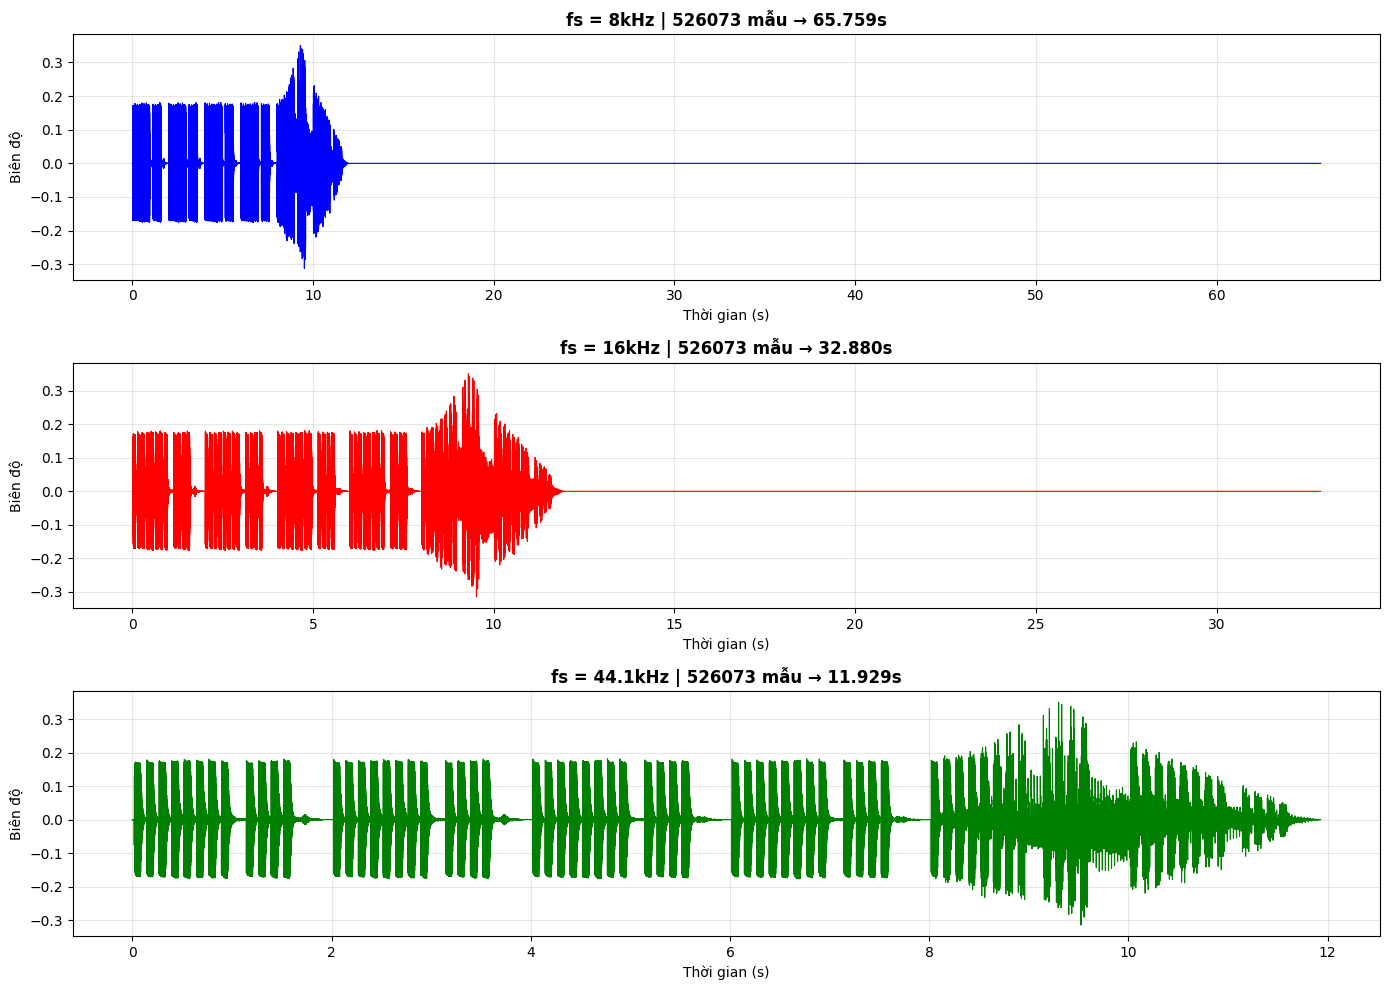

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

#8k
axes[0].plot(t_8k_fixed, signal_8k_fixed, 'b-', linewidth=0.8)
axes[0].set_title(f'fs = 8kHz | {fixed_n_samples} mẫu → {fixed_n_samples/fs_8k:.3f}s', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian (s)')
axes[0].set_ylabel('Biên độ')
axes[0].grid(True, alpha=0.3)

#16k
axes[1].plot(t_16k_fixed, signal_16k_fixed, 'r-', linewidth=0.8)
axes[1].set_title(f'fs = 16kHz | {fixed_n_samples} mẫu → {fixed_n_samples/fs_16k:.3f}s', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thời gian (s)')
axes[1].set_ylabel('Biên độ')
axes[1].grid(True, alpha=0.3)

#44.1k
axes[2].plot(t_44k_fixed, signal_44k_fixed, 'g-', linewidth=0.8)
axes[2].set_title(f'fs = 44.1kHz | {fixed_n_samples} mẫu → {fixed_n_samples/fs_44k:.3f}s', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Thời gian (s)')
axes[2].set_ylabel('Biên độ')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()